# Züri wie neu - Spatial Analysis of Urban Infrastructure Reports in Zurich

## 1. Project Overview
This project analyses reported infrastructure issues in Zurich using open data from the "Züri wie neu" platform, statistical neighbourhood boundaries, and neighbourhood population data.

### 1.1. Data sources
The analysis is based on open geospatial datasets provided by the City of Zurich:

- Züri wie neu reports:
  https://data.stadt-zuerich.ch/dataset/geo_zueri_wie_neu

- Statistical neighbourhoods:
  https://data.stadt-zuerich.ch/dataset/geo_statistische_quartiere

- Population by neighbourhood:
  https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_quartier_od3240

The reports and statistical neighbourhoods datasets were downloaded on 04.05.2026.

The population by neighbourhood dataset was downloaded on 12.05.2026

### 1.2. Research Question 
How are reported infrastructure problems distributed spatially and temporally across the neighbourhoods of the city of Zurich?

### 1.3. Subquestions
1. Which neighbourhoods have the highest number of reports?
2. Which problem categories are most common?
3. Are certain problem categories concentrated in specific neighbourhoods?
4. How do reports develop over time and are there seasonal patterns?

## 2. Load the data
This analysis uses three datasets provided by the City of Zurich. These are infrastructure reports from the Züri wie neu platform, statistical neighbourhood polygons, and neighbourhood population data.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

reports = gpd.read_file("../data/raw/Zueri_wie_neu.gpkg")

neighbourhoods = gpd.read_file("../data/raw/Statistische_Quartiere.gpkg",layer="stzh.adm_statistische_quartiere_v")

population = pd.read_csv("../data/raw/bev324od3240.csv")

## 3. Data Inspection
Before starting the analysis, the structure, columns, coordinate reference system and missing values of both datasets are inspected.

### 3.1. Inspect reports dataset

In [2]:
reports.head()


,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)


In [3]:
reports.shape

(72623, 19)

In [4]:
reports.columns

Index(['objectid', 'service_request_id', 'requested_datetime',
       'agency_sent_datetime', 'updated_datetime', 'e', 'n', 'service_code',
       'service_name', 'status', 'userid', 'title', 'detail', 'media_url',
       'interface_used', 'service_notice', 'description', 'url', 'geometry'],
      dtype='object')

In [5]:
reports.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [6]:
reports.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 72623 entries, 0 to 72622
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              72623 non-null  int32         
 1   service_request_id    72623 non-null  object        
 2   requested_datetime    72623 non-null  datetime64[ms]
 3   agency_sent_datetime  71802 non-null  datetime64[ms]
 4   updated_datetime      72623 non-null  datetime64[ms]
 5   e                     72623 non-null  int32         
 6   n                     72623 non-null  int32         
 7   service_code          72623 non-null  object        
 8   service_name          72623 non-null  object        
 9   status                72623 non-null  object        
 10  userid                72623 non-null  int32         
 11  title                 72623 non-null  object        
 12  detail                72623 non-null  object        
 13  media_ur

In [7]:
reports.isna().sum()

objectid                  0
service_request_id        0
requested_datetime        0
agency_sent_datetime    821
updated_datetime          0
e                         0
n                         0
service_code              0
service_name              0
status                    0
userid                    0
title                     0
detail                    0
media_url                 0
interface_used            0
service_notice            0
description               0
url                       0
geometry                  0
dtype: int64

In [8]:
reports["status"].value_counts()

status
fixed - council     63470
external             8959
jurisdiction unk       81
not contactable        69
wish                   22
confirmed              22
Name: count, dtype: int64

The reports dataset contains point geometries representing reported infrastructure problems across Zurich. It includes information about report dates, problem categories, status information and spatial coordinates. The coordinate reference system is EPSG:2056 (CH1903+ / LV95), which is suitable for spatial analysis in Switzerland.

### 3.2. Inspect neighbourhood dataset

In [9]:
neighbourhoods.head()

,objid,objectid,qname,qnr,kname,knr,geometry
0,1,1,Alt-Wiedikon,31,Kreis 3,3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,10,2,Witikon,74,Kreis 7,7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,11,3,Langstrasse,42,Kreis 4,4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,12,4,Escher Wyss,52,Kreis 5,5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,13,5,Enge,24,Kreis 2,2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


In [10]:
neighbourhoods.shape

(34, 7)

In [11]:
neighbourhoods.columns

Index(['objid', 'objectid', 'qname', 'qnr', 'kname', 'knr', 'geometry'], dtype='object')

In [12]:
neighbourhoods.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [13]:
neighbourhoods.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   objid     34 non-null     object  
 1   objectid  34 non-null     int32   
 2   qname     34 non-null     object  
 3   qnr       34 non-null     int32   
 4   kname     34 non-null     object  
 5   knr       34 non-null     int32   
 6   geometry  34 non-null     geometry
dtypes: geometry(1), int32(3), object(3)
memory usage: 1.6+ KB


In [14]:
neighbourhoods.isna().sum()

objid       0
objectid    0
qname       0
qnr         0
kname       0
knr         0
geometry    0
dtype: int64

The neighbourhood dataset contains polygon geometries representing Zurich’s statistical neighbourhoods. The dataset is also stored in EPSG:2056, ensuring compatibility for spatial analysis and spatial joins.

### 3.3. Inspect population dataset

In [15]:
population.head()

,StichtagDatJahr,QuarSort,QuarLang,AnzBestWir
0,2025,11,Rathaus,3252
1,2024,11,Rathaus,3260
2,2023,11,Rathaus,3343
3,2022,11,Rathaus,3330
4,2021,11,Rathaus,3275


In [16]:
population.shape

(2785, 4)

In [17]:
population.columns

Index(['StichtagDatJahr', 'QuarSort', 'QuarLang', 'AnzBestWir'], dtype='object')

In [18]:
population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2785 entries, 0 to 2784
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   StichtagDatJahr  2785 non-null   int64 
 1   QuarSort         2785 non-null   int64 
 2   QuarLang         2785 non-null   object
 3   AnzBestWir       2785 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 87.2+ KB


In [19]:
population.isna().sum()

StichtagDatJahr    0
QuarSort           0
QuarLang           0
AnzBestWir         0
dtype: int64

The population dataset contains yearly population counts by neighbourhood. It is used to compare report numbers relative to neighbourhood population size.

## 4. Data Cleaning and Preparation
The data is prepared by converting datetime columns, creating temporal variables and selecting only the relevant columns for the analysis.
### 4.1. Convert dateime columns

In [20]:
reports["requested_datetime"] = pd.to_datetime(reports["requested_datetime"])
reports["updated_datetime"] = pd.to_datetime(reports["updated_datetime"])

### 4.2. Creat temporal variables
Additional temporal variables are created from the original datetime column. These variables allow the analysis of trends and seasonal patterns over time.

In [21]:
reports["year"] = reports["requested_datetime"].dt.year
reports["month"] = reports["requested_datetime"].dt.month
reports["weekday"] = reports["requested_datetime"].dt.day_name()

The new temporal variables allow the analysis of yearly trends, monthly patterns and weekday reporting behaviour.

### 4.3. Clean reports dataset
Only relevant variables are kept for the analysis in order to simplify the workflow and improve readability.
For the spatial comparison with population data, the reports dataset is filtered to the year 2025.

For the temporal trend analysis, only complete years between 2014 and 2025 are retained. The years 2013 and 2026 are excluded because they do not contain a full year of observations.

The year 2025 is used for the detailed spatial and seasonal analyses because it contains the highest number of reports and represents a complete reporting year in the dataset.

In [22]:
reports["year"].value_counts().sort_index()

year
2013     2901
2014     2139
2015     1943
2016     2307
2017     2869
2018     3724
2019     5243
2020     4802
2021     5783
2022     6828
2023     8325
2024    10794
2025    11588
2026     3377
Name: count, dtype: int64

In [23]:
## reports over all years
reports_relevant_var = reports[[
    "requested_datetime",
    "updated_datetime",
    "service_name",
    "status",
    "description",
    "year",
    "month",
    "weekday",
    "geometry"
]]

## filter complete years
reports_clean = reports_relevant_var[
    (reports_relevant_var["year"] >= 2014) &
    (reports_relevant_var["year"] <= 2025)
]

## filter reports for 2025
reports_2025 = reports_clean[reports_clean["year"] == 2025]

### 4.4. Clean neighbourhood dataset
Only the neighbourhood name, district name, and geometry are required for the spatial analysis.

In [24]:
neighbourhoods_clean = neighbourhoods[[
    "qname",
    "kname",
    "geometry"
]]

### 4.5. Clean population dataset
The population dataset is filtered for the year 2025. This allows the report counts from 2025 to be compared with population data from the same year.

In [25]:
## rename population columns
population = population.rename(columns={
    "StichtagDatJahr": "year",
    "QuarLang": "qname",
    "AnzBestWir": "population"
})

## filter population data for 2025
population_2025 = population[population["year"] == 2025]

## select relevant population columns
population_2025_clean = population_2025[[
    "qname",
    "population"
]]

### 4.6. Check cleaned data

In [26]:
reports_clean.head()

,requested_datetime,updated_datetime,service_name,status,description,year,month,weekday,geometry
188,2014-05-13 07:33:00,2014-05-13 14:10:04,Strasse/Trottoir/Platz,external,Hydrant ang: Hydrant angefahren,2014,5,Tuesday,POINT (2682906 1248393)
709,2014-02-11 01:22:49,2014-02-12 08:55:04,Graffiti,external,Graffiti an: Graffiti an Mauer unterhalb Althe...,2014,2,Tuesday,POINT (2684062 1249961)
771,2014-08-20 14:49:16,2014-08-20 15:00:05,Strasse/Trottoir/Platz,external,S tropft!: S tropft!,2014,8,Wednesday,POINT (2680531 1249514)
1023,2014-02-15 19:58:01,2014-02-17 12:56:33,Beleuchtung/Uhren,fixed - council,Strassenlam: Strassenlampe defekt,2014,2,Saturday,POINT (2681133 1250273)
1509,2016-06-27 14:31:04,2016-07-01 07:58:40,Brunnen/Hydranten,fixed - council,Brunnen übe: Brunnen überläuft,2016,6,Monday,POINT (2683920 1245604)


In [27]:
reports_2025.head()

,requested_datetime,updated_datetime,service_name,status,description,year,month,weekday,geometry
44670,2025-06-16 20:06:53,2025-06-17 07:07:04,Abfall/Sammelstelle,external,Veloschrott: Veloschrott,2025,6,Monday,POINT (2682447 1247655)
45845,2025-05-12 10:05:31,2025-05-12 10:12:05,Abfall/Sammelstelle,external,Demoliertes: Demoliertes Velo,2025,5,Monday,POINT (2681227 1248047)
45867,2025-05-22 19:41:18,2025-05-26 05:42:43,Beleuchtung/Uhren,fixed - council,Lampe kaput: Lampe kaputt,2025,5,Thursday,POINT (2682870 1247836)
45975,2025-06-29 18:24:09,2025-06-30 12:12:04,Abfall/Sammelstelle,external,Ausgeschlac: Ausgeschlachteter Scooter,2025,6,Sunday,POINT (2681519 1247334)
46705,2025-02-16 22:19:45,2025-04-03 10:26:13,Graffiti,fixed - council,Graffiti: Graffiti,2025,2,Sunday,POINT (2683763 1247000)


In [28]:
neighbourhoods_clean.head()

,qname,kname,geometry
0,Alt-Wiedikon,Kreis 3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,Witikon,Kreis 7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,Langstrasse,Kreis 4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,Escher Wyss,Kreis 5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,Enge,Kreis 2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


In [29]:
population_2025_clean.head()

,qname,population
0,Rathaus,3252
85,Hochschulen,688
170,Lindenhof,1038
255,City,769
340,Wollishofen,22029


## 5. Spatial Join
A spatial join is used to assign each report point to the neighbourhood polygon in which it is located.

In [30]:
reports_with_neighbourhoods = gpd.sjoin(reports_2025,neighbourhoods_clean,how="left",predicate="within")

In [31]:
reports_with_neighbourhoods.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 11588 entries, 44670 to 69270
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   requested_datetime  11588 non-null  datetime64[ms]
 1   updated_datetime    11588 non-null  datetime64[ms]
 2   service_name        11588 non-null  object        
 3   status              11588 non-null  object        
 4   description         11588 non-null  object        
 5   year                11588 non-null  int32         
 6   month               11588 non-null  int32         
 7   weekday             11588 non-null  object        
 8   geometry            11588 non-null  geometry      
 9   index_right         11588 non-null  int64         
 10  qname               11588 non-null  object        
 11  kname               11588 non-null  object        
dtypes: datetime64[ms](2), geometry(1), int32(2), int64(1), object(6)
memory usage: 1.1+ MB


In [32]:
reports_with_neighbourhoods.head()

,requested_datetime,updated_datetime,service_name,status,description,year,month,weekday,geometry,index_right,qname,kname
44670,2025-06-16 20:06:53,2025-06-17 07:07:04,Abfall/Sammelstelle,external,Veloschrott: Veloschrott,2025,6,Monday,POINT (2682447 1247655),2,Langstrasse,Kreis 4
45845,2025-05-12 10:05:31,2025-05-12 10:12:05,Abfall/Sammelstelle,external,Demoliertes: Demoliertes Velo,2025,5,Monday,POINT (2681227 1248047),29,Hard,Kreis 4
45867,2025-05-22 19:41:18,2025-05-26 05:42:43,Beleuchtung/Uhren,fixed - council,Lampe kaput: Lampe kaputt,2025,5,Thursday,POINT (2682870 1247836),15,City,Kreis 1
45975,2025-06-29 18:24:09,2025-06-30 12:12:04,Abfall/Sammelstelle,external,Ausgeschlac: Ausgeschlachteter Scooter,2025,6,Sunday,POINT (2681519 1247334),17,Sihlfeld,Kreis 3
46705,2025-02-16 22:19:45,2025-04-03 10:26:13,Graffiti,fixed - council,Graffiti: Graffiti,2025,2,Sunday,POINT (2683763 1247000),30,Hochschulen,Kreis 1


With the spatial join each report point from 2025 is used to assign to the neighbourhood polygon in which it is located.
## 6. Spatial analysis
### 6.1. Reports per neighbourhood
This section answers the question of which neighbourhoods have the highest number of reports in 2025. The reports are counted per neighbourhood and visualised as a choropleth map.

In [33]:
reports_per_neighbourhood = (reports_with_neighbourhoods
    .groupby("qname")
    .size()
    .reset_index(name="report_count")
)

### 6.2. Merge counts with neighbourhood polygons

In [34]:
neighbourhoods_merged = neighbourhoods_clean.merge(reports_per_neighbourhood, on="qname", how="left")

### 6.3. Choropleth map with relative data
This choropleth map visualizes the absolute number of infrastructure reports per neighbourhood in 2025. 

The map uses Natural Breaks classification because it groups neighbourhoods with similar report counts. Five classes were chosen to balance detail and readability.

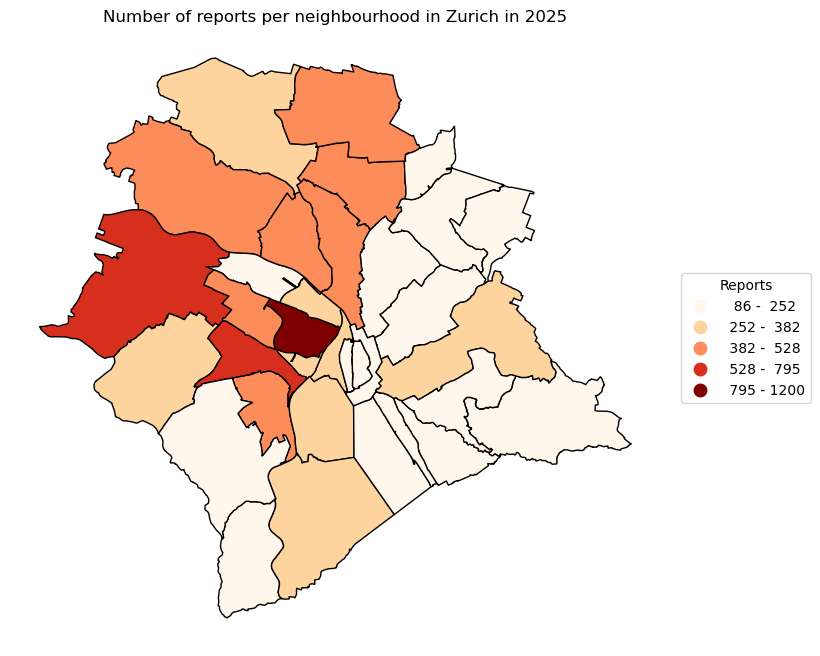

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))

neighbourhoods_merged.plot(
    column="report_count",
    cmap="OrRd",
    scheme="NaturalBreaks",
    k=5,
    legend=True,
    edgecolor="black",
    ax=ax,
    legend_kwds={
        "title": "Reports",
        "loc": "center left",
        "bbox_to_anchor": (1.02, 0.5),
        "fmt": "{:.0f}"
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No reports"
    }
)

legend = ax.get_legend()
labels = [text.get_text() for text in legend.get_texts()]
new_labels = [label.replace(",", " -") for label in labels]

for text, label in zip(legend.get_texts(), new_labels):
    text.set_text(label)

plt.title("Number of reports per neighbourhood in Zurich in 2025")
plt.axis("off")
plt.show()

The map shows clear spatial differences between neighbourhoods. Darker areas indicate neighbourhoods with higher numbers of reported infrastructure issues.

### 6.4 Reports normalized by population

Absolute report counts can be influenced by neighbourhood population size. Larger neighbourhoods may naturally contain more reports because more people live there.

Therefore, the number of reports is additionally normalized by population and expressed as reports per 1'000 residents. This allows a fairer comparison between neighbourhoods.

In [36]:
## merge neighbourhood report counts with population data
neighbourhoods_population = neighbourhoods_merged.merge(population_2025_clean,on="qname",how="left")

## calculate reports per 1'000 residents
neighbourhoods_population["reports_per_1000"] = (
    neighbourhoods_population["report_count"] /
    neighbourhoods_population["population"] * 1000)

## calculate reports per 1,000 residents
neighbourhoods_population.head()

,qname,kname,geometry,report_count,population,reports_per_1000
0,Alt-Wiedikon,Kreis 3,"POLYGON ((2680606.662 1247034.584, 2680626.356...",456,18904,24.121879
1,Witikon,Kreis 7,"POLYGON ((2685858.632 1246502.629, 2685860.738...",170,11984,14.185581
2,Langstrasse,Kreis 4,"POLYGON ((2681313.304 1248613.857, 2681459.605...",1200,11978,100.183670
3,Escher Wyss,Kreis 5,"POLYGON ((2680009.144 1249565.021, 2680055.843...",212,6426,32.990974
4,Enge,Kreis 2,"POLYGON ((2681898.171 1246379.668, 2681899.115...",360,10015,35.946081


### 6.5. Choropleth map with normalized data

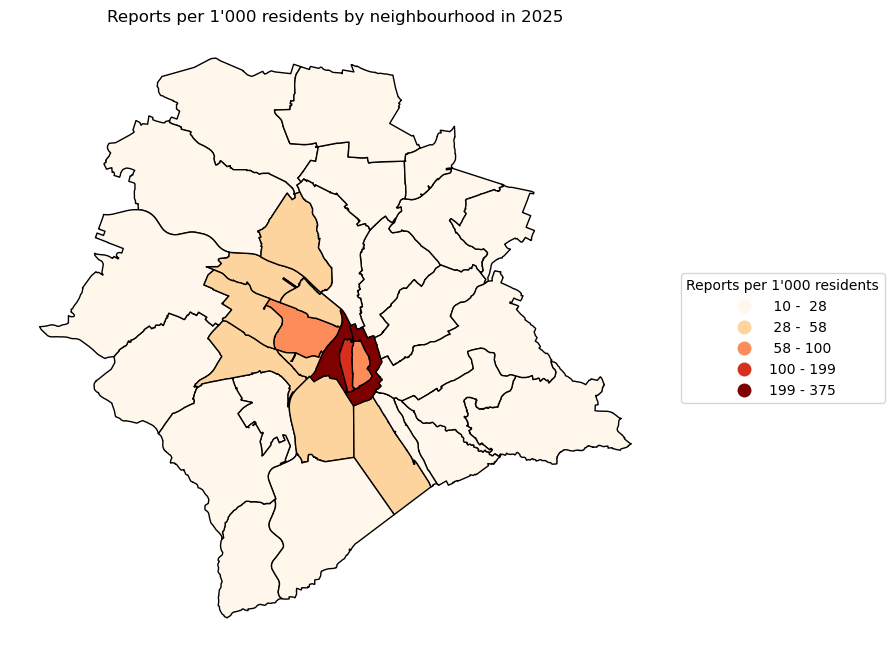

In [37]:
fig, ax = plt.subplots(figsize=(10, 8))

neighbourhoods_population.plot(
    column="reports_per_1000",
    cmap="OrRd",
    scheme="NaturalBreaks",
    k=5,
    legend=True,
    edgecolor="black",
    ax=ax,
    legend_kwds={
        "title": "Reports per 1'000 residents",
        "loc": "center left",
        "bbox_to_anchor": (1.02, 0.5),
        "fmt": "{:.0f}"
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

legend = ax.get_legend()
labels = [text.get_text() for text in legend.get_texts()]
new_labels = [label.replace(",", " -") for label in labels]

for text, label in zip(legend.get_texts(), new_labels):
    text.set_text(label)

plt.title("Reports per 1'000 residents by neighbourhood in 2025")
plt.axis("off")
plt.show()

The normalized map shows how report patterns change when neighbourhood population size is considered. Some neighbourhoods with high absolute report counts may appear less dominant after normalization, while smaller neighbourhoods may show relatively high reporting rates.

### 6.6. Comparison of the absolut and normalized map
The side-by-side comparison highlights differences between absolute report counts and population-normalized reporting rates. This allows a better understanding of how neighbourhood size influences report patterns.

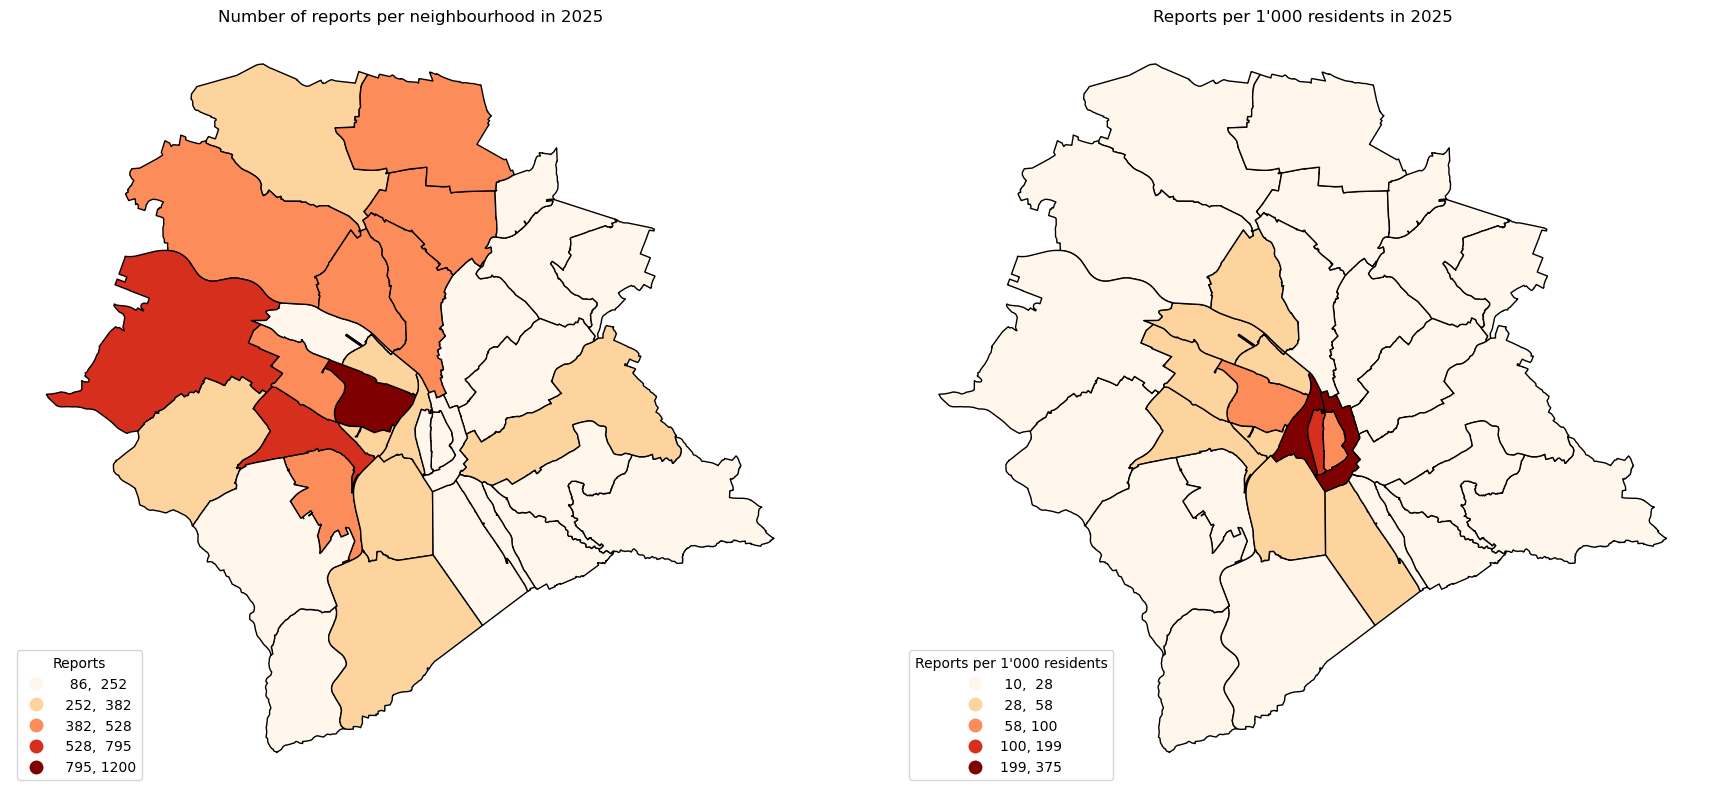

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

## absolute reports
neighbourhoods_merged.plot(
    column="report_count",
    cmap="OrRd",
    scheme="NaturalBreaks",
    k=5,
    legend=True,
    edgecolor="black",
    ax=axes[0],
    legend_kwds={
        "title": "Reports",
        "loc": "lower left",
        "fmt": "{:.0f}"
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

axes[0].set_title("Number of reports per neighbourhood in 2025")
axes[0].axis("off")

## relative reports
neighbourhoods_population.plot(
    column="reports_per_1000",
    cmap="OrRd",
    scheme="NaturalBreaks",
    k=5,
    legend=True,
    edgecolor="black",
    ax=axes[1],
    legend_kwds={
        "title": "Reports per 1'000 residents",
        "loc": "lower left",
        "fmt": "{:.0f}"
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

axes[1].set_title("Reports per 1'000 residents in 2025")
axes[1].axis("off")

plt.tight_layout()

plt.show()

## 7. Category Analysis
This section analyses which types of infrastructure problems are most frequently reported.

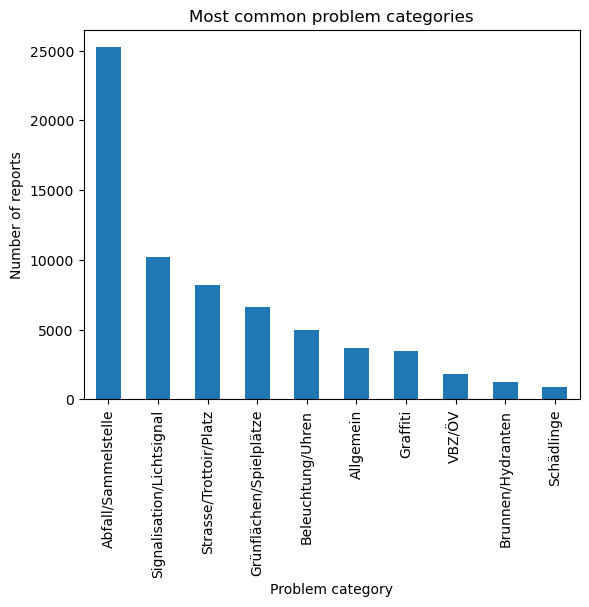

In [39]:
reports_clean["service_name"].value_counts().plot(kind="bar")

plt.title("Most common problem categories")
plt.xlabel("Problem category")
plt.ylabel("Number of reports")
plt.xticks(rotation=90)
plt.show()

The category distribution shows which types of problems dominate the Züri wie neu reports. This helps to understand the main types of infrastructure issues reported by residents.
## 8. Concentration of problem categories by neighbourhood
This section examines whether certain problem categories are concentrated in specific neighbourhoods.

In [40]:
category_by_neighbourhood = pd.crosstab(
    reports_with_neighbourhoods["qname"],
    reports_with_neighbourhoods["service_name"]
)

category_by_neighbourhood.head()

service_name,Abfall/Sammelstelle,Allgemein,Beleuchtung/Uhren,Brunnen/Hydranten,Graffiti,Grünflächen/Spielplätze,Schädlinge,Signalisation/Lichtsignal,Strasse/Trottoir/Platz,VBZ/ÖV
qname,,,,,,,,,,
Affoltern,129,24,23,3,7,44,3,62,27,9
Albisrieden,122,15,24,11,11,40,7,84,42,4
Alt-Wiedikon,259,50,25,4,9,25,5,39,30,10
Altstetten,244,55,39,25,25,55,10,117,50,8
City,75,40,21,4,11,13,0,62,44,18


The cross-tabulation shows how often each problem category appears in each neighbourhood. This allows comparison of category patterns across Zurich.

The analysis focuses on selected problem categories that occur frequently in the dataset and represent different types of urban infrastructure issues. Using a limited number of categories improves the readability and interpretability of the visualisation.

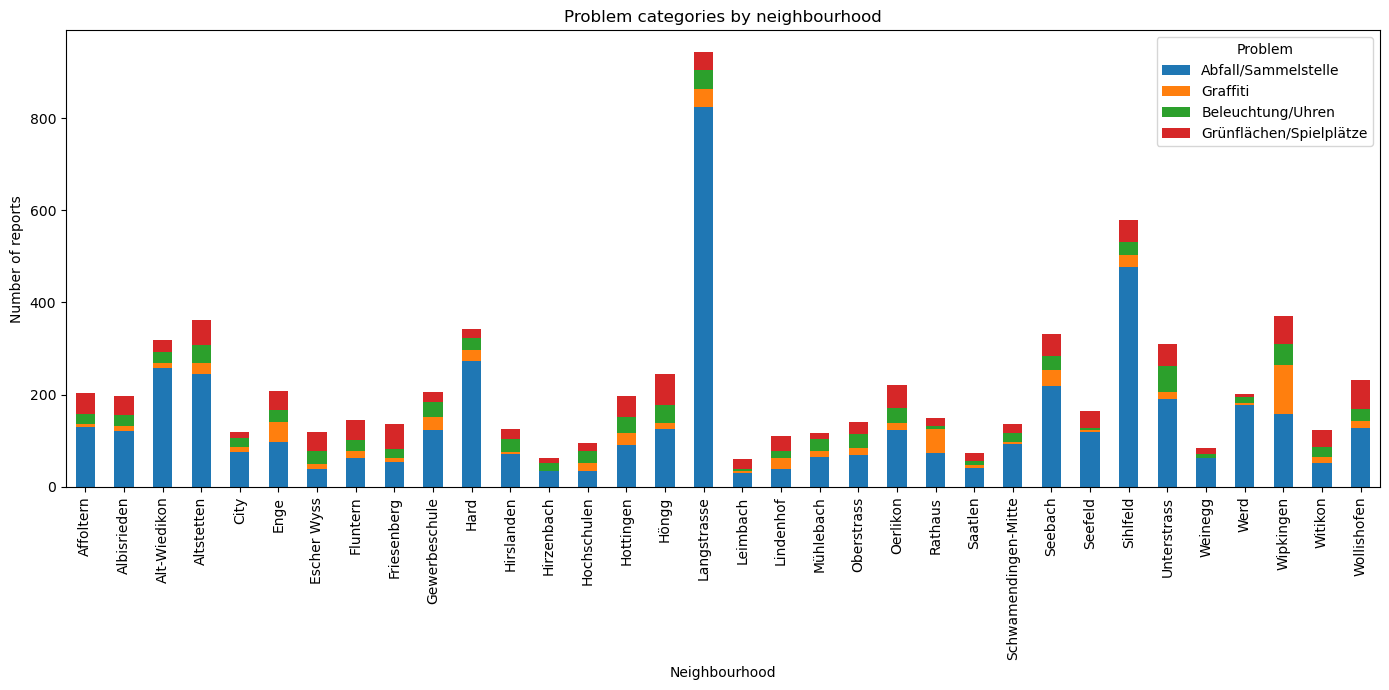

In [41]:
top_categories = category_by_neighbourhood[[
    "Abfall/Sammelstelle",
    "Graffiti",
    "Beleuchtung/Uhren",
    "Grünflächen/Spielplätze"
]]

top_categories.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Problem categories by neighbourhood")
plt.xlabel("Neighbourhood")
plt.ylabel("Number of reports")
plt.xticks(rotation=90)
plt.legend(title="Problem")
plt.tight_layout()

plt.show()

The stacked bar chart highlights differences in the composition of problem categories between neighbourhoods.

## 9. Temporal Analysis
This section analyses how the number of reports changes over time and whether temporal patterns can be observed.

### 9.1. Reports over years


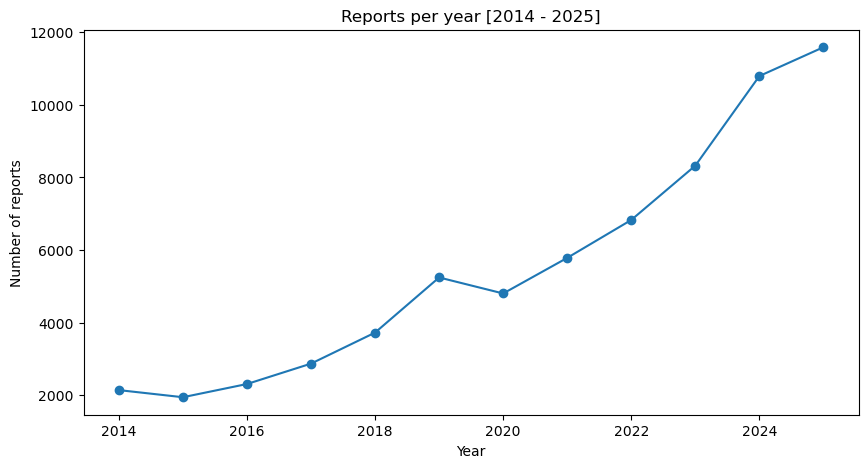

In [42]:
reports_clean.groupby("year").size().plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Reports per year [2014 - 2025]")
plt.xlabel("Year")
plt.ylabel("Number of reports")

plt.show()

### 9.2. Seasonal patterns within the year

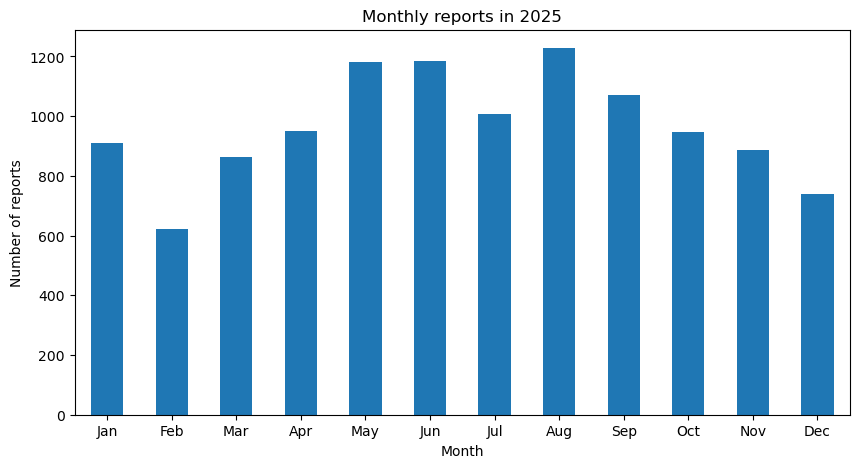

In [43]:
reports_2025 = reports_clean[reports_clean["year"] == 2025]

monthly_reports = reports_2025.groupby("month").size()

monthly_reports.plot(
    kind="bar",
    figsize=(10,5)
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.title("Monthly reports in 2025")
plt.xlabel("Month")
plt.ylabel("Number of reports")
plt.xticks(
    ticks=range(12),
    labels=month_labels,
    rotation=0
)

plt.show()

### 9.3. Reports by weekday
This analysis examines whether reports are more frequently submitted on certain weekdays.

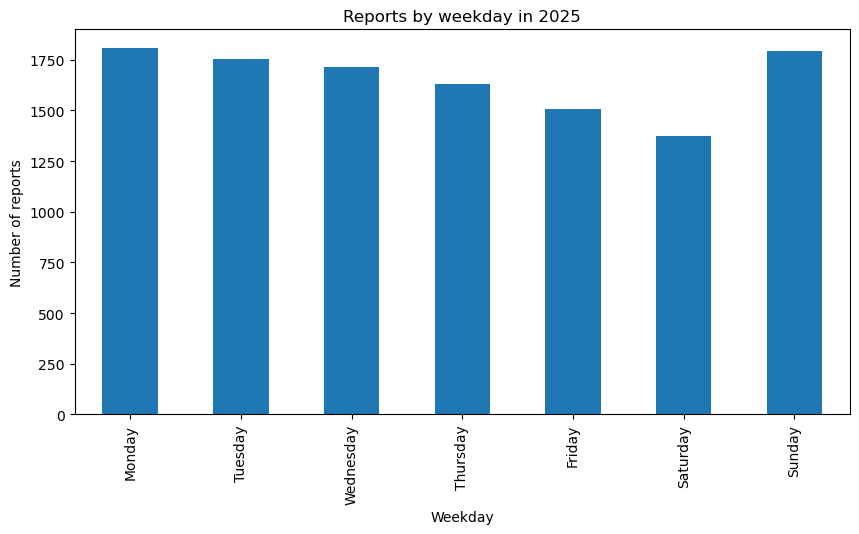

In [44]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

reports_by_weekday = (
    reports_2025["weekday"]
    .value_counts()
    .reindex(weekday_order)
)

reports_by_weekday.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Reports by weekday in 2025")
plt.xlabel("Weekday")
plt.ylabel("Number of reports")

plt.show()

## 10. Conclusion
The analysis shows that reported infrastructure issues are not evenly distributed across Zurich. Some neighbourhoods receive considerably more reports than others, and certain problem categories are more common. The temporal analysis also shows changes over time and possible seasonal or weekday-related reporting patterns.

## 11. Limitations and possible improvements
**Limitations**

This analysis is based on reported infrastructure problems, not necessarily all existing problems. Neighbourhoods with more active residents, higher foot traffic, or better awareness of the Züri wie neu platform may have more reports.

The population-normalized map improves comparability, but it does not account for daytime population, commuters, tourists, or land-use differences between neighbourhoods.

**Possible improvements**

Future improvements could include interactive web maps, hotspot analysis, normalization by neighbourhood area, or comparison with land-use and transport data.
